# MTA Subway Delay Prediction\n\nPredicting subway segment delays (`avg_actual_runtime - avg_scheduled_runtime`) from MTA's published running-time data using linear regression.\n\n**Data source:** `mta_project.running_times` (MySQL) — one row per line/direction/stop-segment/time-period/month, ~140K rows.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Load data from MySQL

Credentials are read from a local `.env` file (gitignored) — never hardcode DB passwords in the notebook.

In [2]:
load_dotenv()

DB_HOST = os.getenv("DB_HOST", "127.0.0.1")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_USER = os.getenv("DB_USER", "root")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")
DB_NAME = os.getenv("DB_NAME", "mta_project")

engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

query = """
SELECT
    line,
    direction,
    time_period,
    schedule_day_type,
    month_date,
    number_of_stops,
    distance,
    scheduled_trains,
    actual_trains,
    avg_scheduled_runtime,
    avg_actual_runtime
FROM running_times
WHERE avg_scheduled_runtime IS NOT NULL
  AND avg_actual_runtime IS NOT NULL
  AND schedule_day_type != ''
"""

df = pd.read_sql(query, engine)
print(df.shape)
df.head()

(139919, 11)


,line,direction,time_period,schedule_day_type,month_date,number_of_stops,distance,scheduled_trains,actual_trains,avg_scheduled_runtime,avg_actual_runtime
0,2,S,AM peak,Saturday,2019-01-01,25,13.68,21,20,48.74,52.32
1,7,S,AM peak,Saturday,2019-01-01,8,3.42,22,22,9.50,12.03
2,7,S,AM peak,Saturday,2019-01-01,15,6.21,66,65,24.50,24.42
3,E,S,AM peak,Saturday,2019-01-01,23,16.29,15,10,51.77,52.61
4,Q,N,AM peak,Saturday,2019-01-01,29,17.93,72,45,60.39,63.06


## 2. Define the target and clean up

Target: **`delay_min` = `avg_actual_runtime` − `avg_scheduled_runtime`** (minutes late, per line/direction/segment/time-period/month). Positive = ran slower than scheduled.

We deliberately leave out a few columns that are only known *after* the fact and would leak the target:
- `p25/p50/p75_runtime` and `avg_speed` are all derived from the same actual-runtime measurement as the target — including them would make the model trivially "predict" delay from itself.
- `stop_path_id` / station names are high-cardinality identifiers already summarized by `line` + `direction` + `number_of_stops` + `distance`.

That leaves features that are knowable from the schedule/context: `line`, `direction`, `time_period`, `schedule_day_type`, `month`, `number_of_stops`, `distance`, `scheduled_trains`, `avg_scheduled_runtime`. We also keep `actual_trains` out of the main feature set since it's a same-period outcome, not a planning input — see the note in section 4.

In [3]:
df["month_date"] = pd.to_datetime(df["month_date"])
df["month"] = df["month_date"].dt.month
df["year"] = df["month_date"].dt.year

df["delay_min"] = df["avg_actual_runtime"] - df["avg_scheduled_runtime"]

# drop rows with impossible/garbage values
df = df[(df["distance"] > 0) & (df["number_of_stops"] > 0) & (df["scheduled_trains"] > 0)]

# clip extreme outliers in the target (data entry errors, sensor glitches) at the 1st/99th pct
lo, hi = df["delay_min"].quantile([0.01, 0.99])
df = df[df["delay_min"].between(lo, hi)]

print(df.shape)
df["delay_min"].describe()

(122813, 14)


count    122813.000000
mean          1.280578
std           2.784946
min          -6.440000
25%          -0.310000
50%           1.030000
75%           2.770000
max          11.510000
Name: delay_min, dtype: float64

## 3. Quick EDA

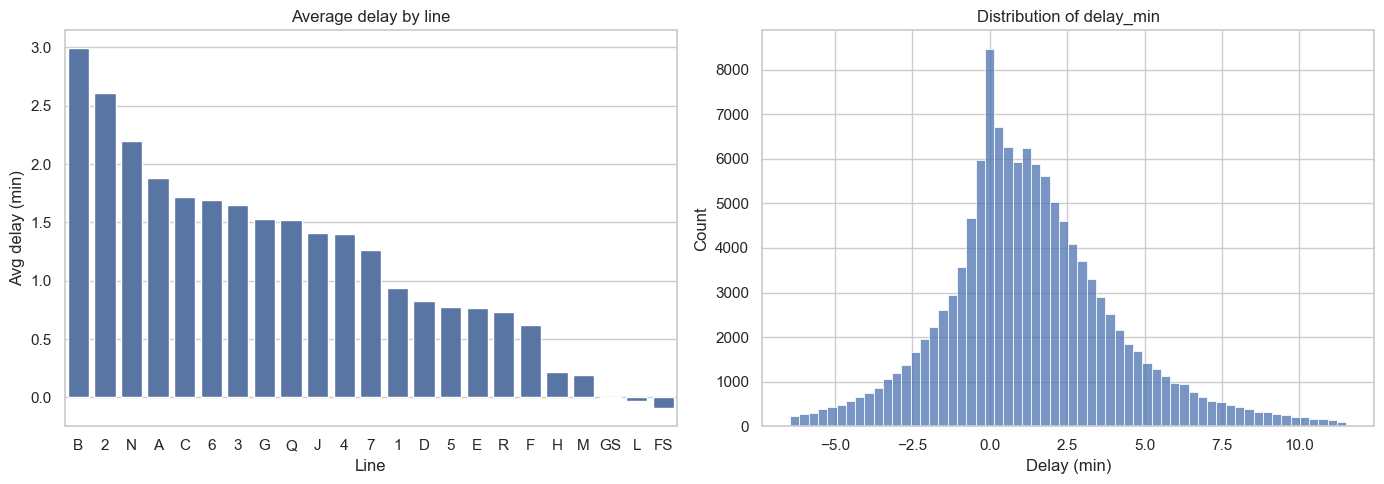

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

line_delay = df.groupby("line")["delay_min"].mean().sort_values(ascending=False)
sns.barplot(x=line_delay.index, y=line_delay.values, ax=axes[0], color="#4C72B0")
axes[0].set_title("Average delay by line")
axes[0].set_ylabel("Avg delay (min)")
axes[0].set_xlabel("Line")

sns.histplot(df["delay_min"], bins=60, ax=axes[1], color="#4C72B0")
axes[1].set_title("Distribution of delay_min")
axes[1].set_xlabel("Delay (min)")

plt.tight_layout()
plt.show()

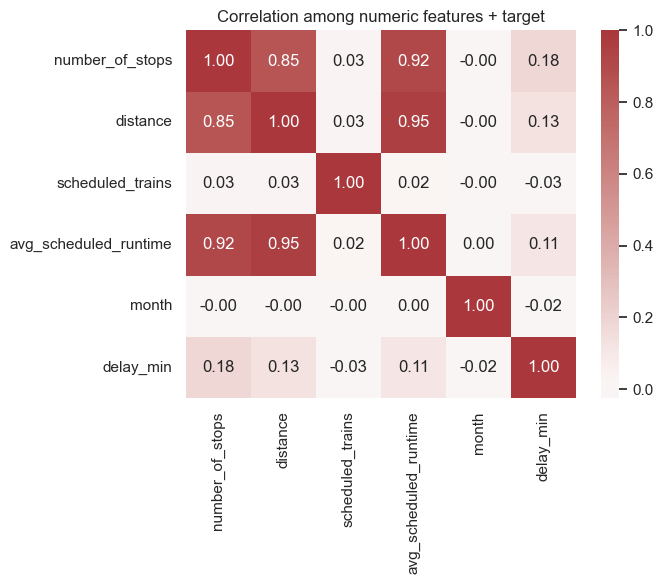

In [5]:
numeric_cols = ["number_of_stops", "distance", "scheduled_trains", "avg_scheduled_runtime", "month", "delay_min"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation among numeric features + target")
plt.tight_layout()
plt.show()

## 4. Features, target, and train/test split

Split is **chronological** (train on earlier months, test on later months) rather than random. A random row-level split would let near-duplicate rows for the same line/segment/month leak between train and test and overstate accuracy — a time-based split is a fairer test of "can this model predict delays it hasn't seen yet."

In [6]:
categorical_features = ["line", "direction", "time_period", "schedule_day_type"]
numeric_features = ["number_of_stops", "distance", "scheduled_trains", "avg_scheduled_runtime", "month"]
target = "delay_min"

feature_cols = categorical_features + numeric_features
model_df = df[feature_cols + [target, "month_date"]].dropna()

print("date range:", model_df["month_date"].min().date(), "to", model_df["month_date"].max().date())

cutoff = model_df["month_date"].quantile(0.8, interpolation="nearest")
print("train/test cutoff:", cutoff.date())

train_df = model_df[model_df["month_date"] <= cutoff]
test_df = model_df[model_df["month_date"] > cutoff]

X_train, y_train = train_df[feature_cols], train_df[target]
X_test, y_test = test_df[feature_cols], test_df[target]

print(f"train: {X_train.shape}, test: {X_test.shape}")

date range: 2019-01-01 to 2026-05-01
train/test cutoff: 2025-01-01
train: (98740, 9), test: (24073, 9)


## 5. Build the linear regression pipeline

`ColumnTransformer` one-hot encodes the categoricals and standardizes the numeric features; `Pipeline` wraps that together with `LinearRegression` so the same fitted transform is reused for train/test/future predictions.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['line', 'direction',
                                                   'time_period',
                                                   'schedule_day_type']),
                                                 ('num', StandardScaler(),
                                                  ['number_of_stops',
                                                   'distance',
                                                   'scheduled_trains',
                                                   'avg_scheduled_runtime',
                                                   'month'])])),
                ('regressor', LinearRegression())])

## 6. Evaluate

In [8]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R^2:  {r2:.3f}")
print(f"MAE:  {mae:.3f} min")
print(f"RMSE: {rmse:.3f} min")

# 5-fold CV on the training set only, as a sanity check against the single time-based split
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
print(f"\n5-fold CV R^2 on train: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

R^2:  0.139
MAE:  1.773 min
RMSE: 2.387 min



5-fold CV R^2 on train: 0.093 (+/- 0.096)


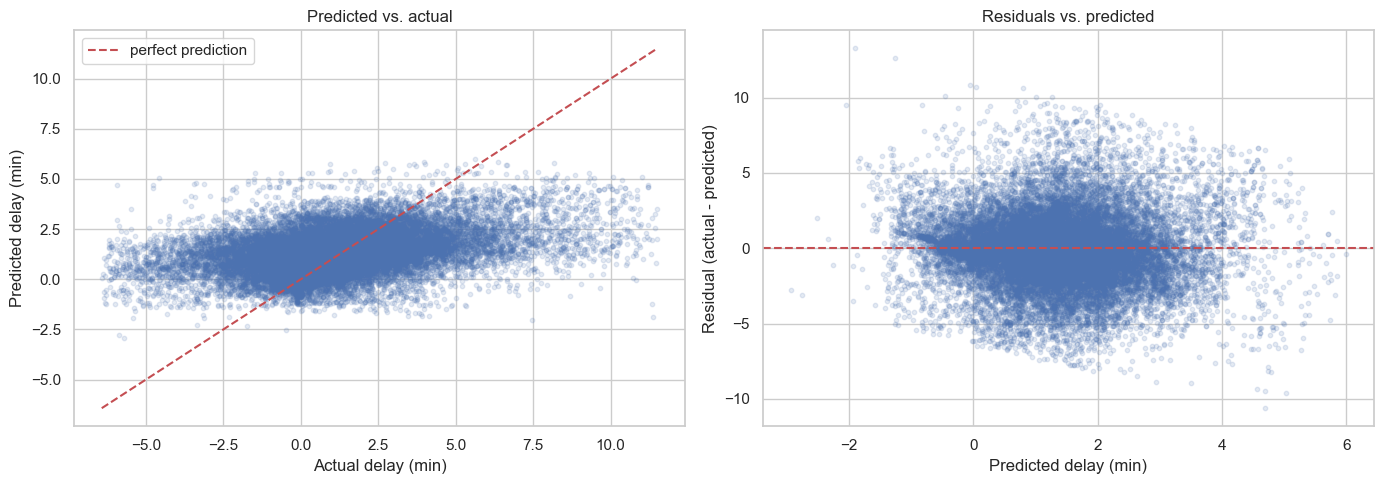

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.15, s=10, color="#4C72B0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color="#C44E52", linestyle="--", label="perfect prediction")
axes[0].set_xlabel("Actual delay (min)")
axes[0].set_ylabel("Predicted delay (min)")
axes[0].set_title("Predicted vs. actual")
axes[0].legend()

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.15, s=10, color="#4C72B0")
axes[1].axhline(0, color="#C44E52", linestyle="--")
axes[1].set_xlabel("Predicted delay (min)")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residuals vs. predicted")

plt.tight_layout()
plt.show()

## 7. Feature importance

Since numeric features are standardized, the fitted coefficients are directly comparable — larger magnitude means a bigger effect on predicted delay per standard-deviation (numeric) or relative-to-baseline (one-hot) change.

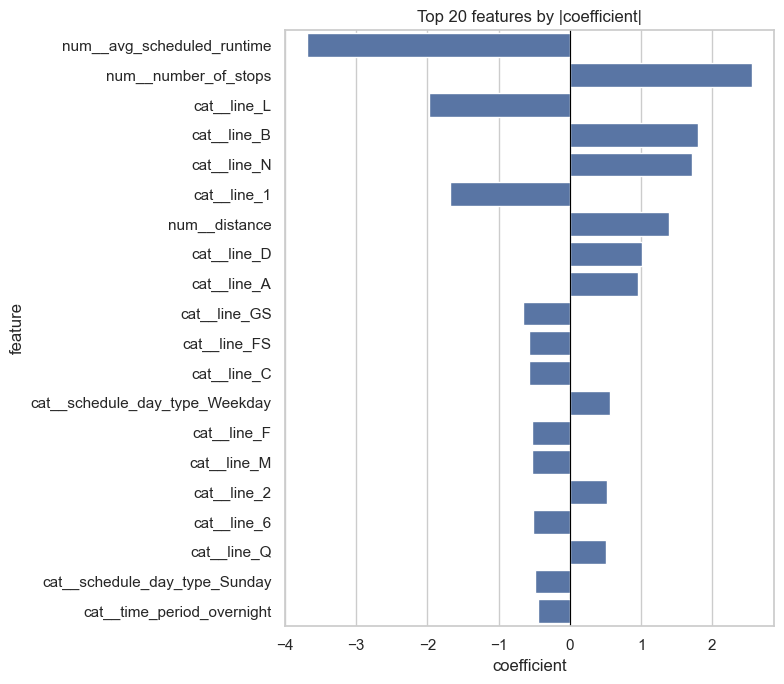

In [10]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefs = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index).head(20)

plt.figure(figsize=(8, 7))
sns.barplot(data=coef_df, x="coefficient", y="feature", color="#4C72B0")
plt.title("Top 20 features by |coefficient|")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## 8. Notes / possible next steps

- If R² is low, that's expected for a first pass — schedule-known features (line, stops, distance, time of day) only partly explain delay; unmodeled causes (weather, incidents, ridership surges) aren't in this dataset.
- Try adding `actual_trains` (or `scheduled_trains - actual_trains` as a "service gap" feature) as a separate experiment — it's a legitimate predictor if you're willing to treat it as "known at prediction time," but it does blur the schedule-only framing above.
- Compare against a regularized variant (`Ridge`/`Lasso`) to see if the many one-hot columns are overfitting.
- Try a non-linear baseline (e.g. `RandomForestRegressor`) as a comparison point for how much linearity is costing you.

## 9. Random Forest comparison

Same features, same chronological train/test split (`X_train`/`y_train`/`X_test`/`y_test` from section 4), same target (`delay_min`). This isolates the effect of model choice — a non-linear, tree-based model vs. the linear baseline above.

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

rf_model = Pipeline(steps=[
    ("preprocess", rf_preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['line', 'direction',
                                                   'time_period',
                                                   'schedule_day_type']),
                                                 ('num', StandardScaler(),
                                                  ['number_of_stops',
                                                   'distance',
                                                   'scheduled_trains',
                                                   'avg_scheduled_runtime',
                                                   'month'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [12]:
rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)

print(f"R^2:  {rf_r2:.3f}")
print(f"MAE:  {rf_mae:.3f} min")
print(f"RMSE: {rf_rmse:.3f} min")

R^2:  0.338
MAE:  1.482 min
RMSE: 2.093 min


### Side-by-side comparison

In [13]:
comparison = pd.DataFrame({
    "Linear Regression": [r2, mae, rmse],
    "Random Forest": [rf_r2, rf_mae, rf_rmse],
}, index=["R^2", "MAE (min)", "RMSE (min)"])

comparison

,Linear Regression,Random Forest
R^2,0.139251,0.338179
MAE (min),1.772996,1.482069
RMSE (min),2.386795,2.092893


### Random Forest feature importances

`RandomForestRegressor.feature_importances_` gives mean decrease in impurity per feature (post one-hot/scaling, same as the linear coefficients above) — not directly comparable in units to the LR coefficients, but useful for ranking which factors the forest relied on most.

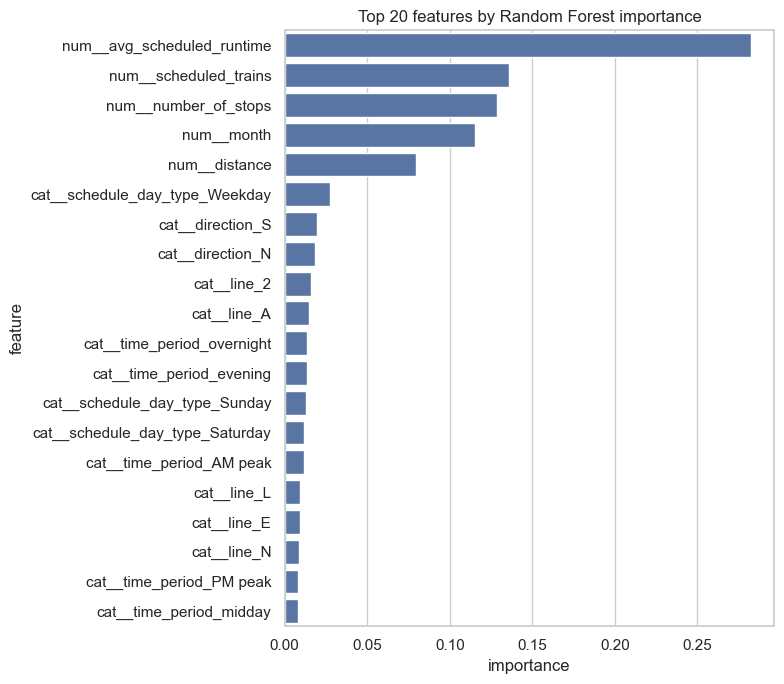

In [14]:
rf_feature_names = rf_model.named_steps["preprocess"].get_feature_names_out()
rf_importances = rf_model.named_steps["regressor"].feature_importances_

rf_imp_df = pd.DataFrame({"feature": rf_feature_names, "importance": rf_importances})
rf_imp_df = rf_imp_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 7))
sns.barplot(data=rf_imp_df, x="importance", y="feature", color="#4C72B0")
plt.title("Top 20 features by Random Forest importance")
plt.tight_layout()
plt.show()